TASK1

In [33]:
#1
import pandas as pd
import numpy as np

df=pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [35]:
missing_values = df.isnull().sum()
missing_values

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [36]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [37]:
df.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

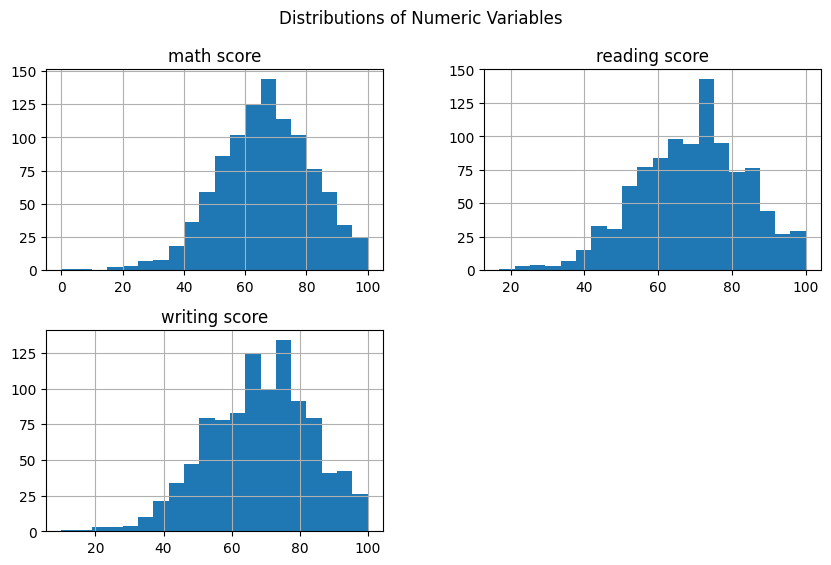

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize=(10, 6), bins=20)
plt.suptitle("Distributions of Numeric Variables")
plt.show()

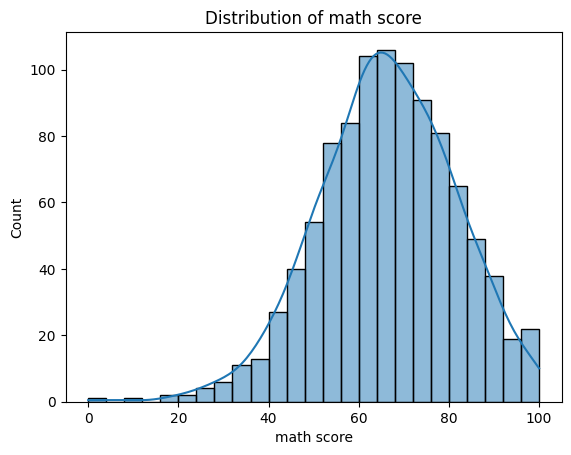

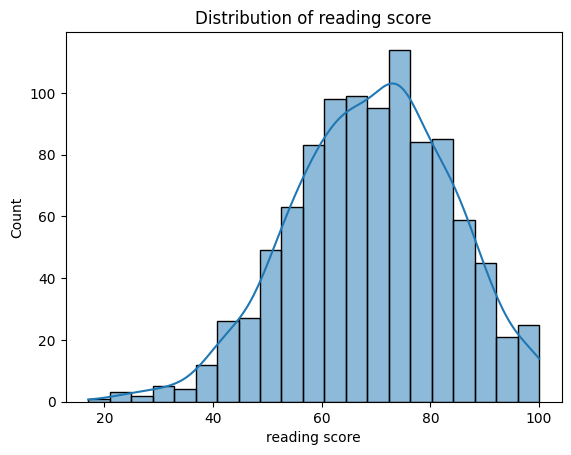

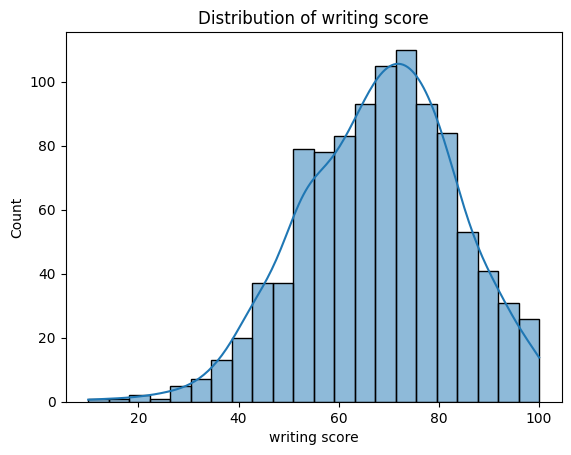

In [39]:
numeric_cols = ['math score', 'reading score', 'writing score']

for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

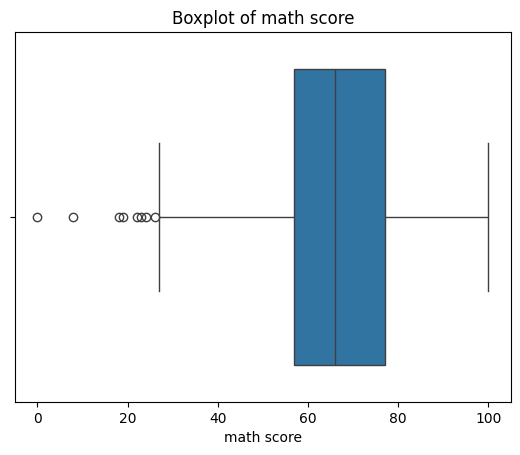

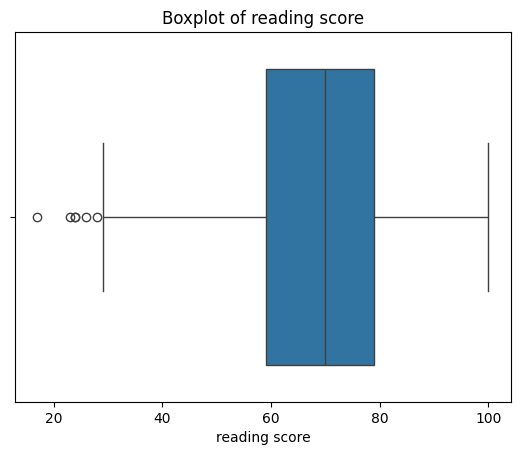

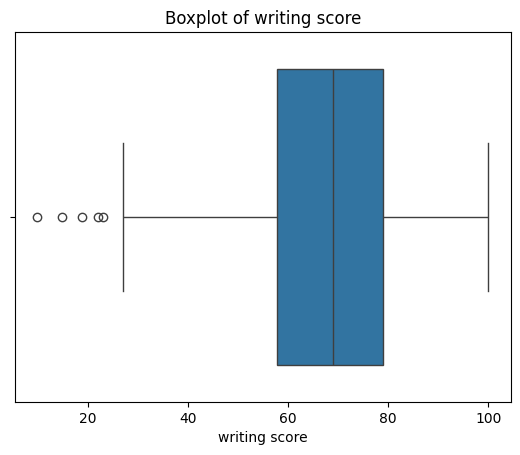

In [40]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

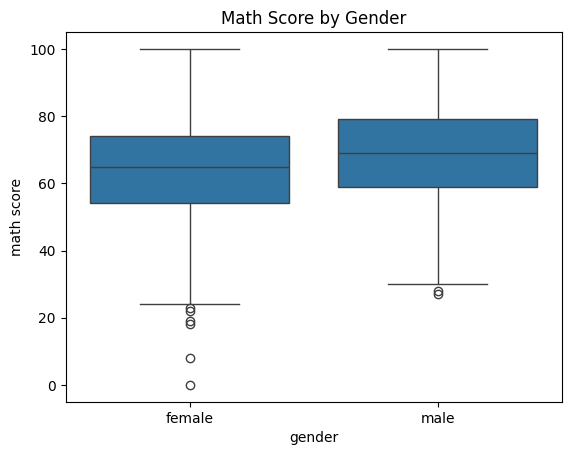

In [41]:
sns.boxplot(x='gender', y='math score', data=df)
plt.title("Math Score by Gender")
plt.show()

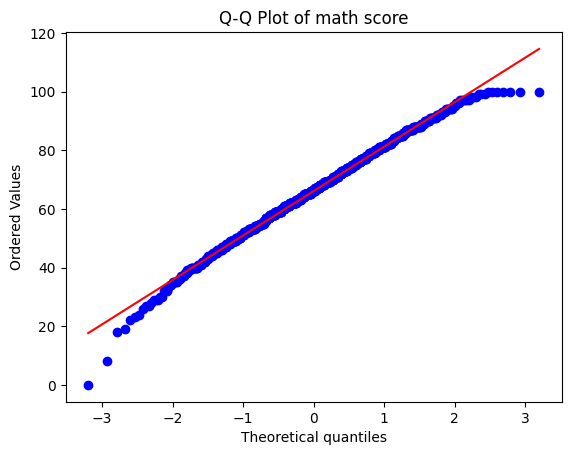

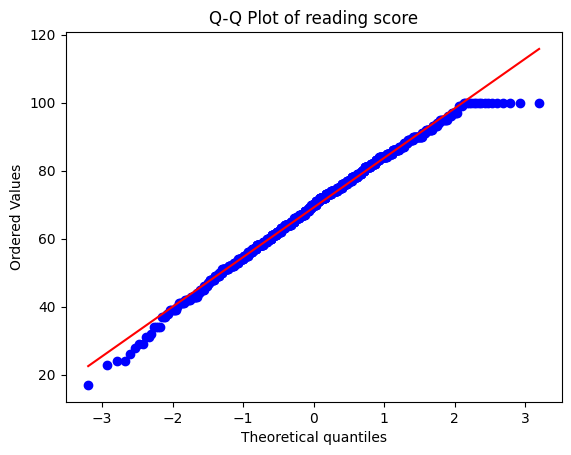

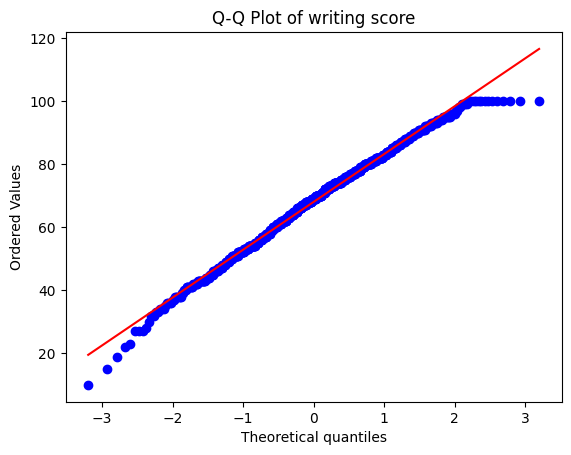

In [42]:
#2
import scipy.stats as stats

for col in numeric_cols:
    plt.figure()
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(f"Q-Q Plot of {col}")
    plt.show()

The Q-Q plot for writing scores shows that most data points lie close to the reference line, indicating approximate normality. However, slight deviations are observed at the tails, particularly at higher values, suggesting a minor ceiling effect. Overall, the normality assumption is reasonably satisfied.

In [43]:
#shapiro test
from scipy.stats import shapiro

for col in numeric_cols:
    stat, p = shapiro(df[col])
    print(f"{col}: p-value = {p}")

math score: p-value = 0.00014545719606603633
reading score: p-value = 0.00010554314738064095
writing score: p-value = 2.9215498810124692e-05


In [44]:
#levene test
from scipy.stats import levene

group1 = df[df['gender'] == 'male']['math score']
group2 = df[df['gender'] == 'female']['math score']

stat, p = levene(group1, group2)
print("Levene p-value:", p)

Levene p-value: 0.5563091575202143


Levene’s test for equality of variances yielded a p-value of 0.556 (> 0.05), indicating that the assumption of homogeneity of variances is satisfied. Therefore, equal variances can be assumed for subsequent t-tests.

1. Normality Assumption
Q-Q plots and Shapiro-Wilk test used.

Q-Q plots show that most data points lie close to the reference line.
Minor deviations are observed at the tails, particularly at higher values (ceiling effect near 100).
If Shapiro-Wilk test is significant (p < 0.05), it suggests slight non-normality.

There is a minor violation of normality due to:
Tail deviations
Bounded nature of scores (0–100)

This violation is not severe because 
sample size is large (~1000) and data is approximately symmetric.

Therefore:
Parametric tests (t-test, ANOVA) are still appropriate
Central Limit Theorem supports robustness.


2. Homogeneity of Variance
Levene’s Test used
Result: p-value = 0.556 (> 0.05)
No violation — variances are equal across groups.

TASK2

1
Do male and female students differ in their average math scores?
a. Hypotheses
H₀ (Null): There is no difference in mean math scores between male and female students
H₁ (Alternative): There is a difference in mean math scores between male and female students
b. Test Justification
Dependent variable: math score (numeric)
Independent variable: gender (2 groups)
Assumptions: approximately normal, equal variances (Levene p > 0.05)

Used Test:Independent samples t-test

In [45]:
from scipy.stats import ttest_ind
import numpy as np

male = df[df['gender'] == 'male']['math score']
female = df[df['gender'] == 'female']['math score']

t_stat, p_val = ttest_ind(male, female, equal_var=True)

# Effect size (Cohen's d)
d = (male.mean() - female.mean()) / np.sqrt((male.std()**2 + female.std()**2) / 2)

print("t-stat:", t_stat)
print("p-value:", p_val)
print("Cohen's d:", d)

t-stat: 5.383245869828983
p-value: 9.120185549328806e-08
Cohen's d: 0.3411535959061146


In [46]:
if p < 0.05:
    print("There is a statistically significant difference in math scores between male and female students.")

if p > 0.05:
    print("There is no meaningful difference in math scores between male and female students.")

There is no meaningful difference in math scores between male and female students.


So as the result of hypotheses we see that male and female students don't differ in their average math scores.

2
Does parental level of education affect writing scores?
a. Hypotheses
H₀: All group means are equal
H₁: At least one group mean is different
b. Test Justification
Independent variable: multiple groups (education levels)
Dependent variable: writing score (numeric)

Used test: One-way ANOVA

In [47]:
from scipy.stats import f_oneway

groups = [group['writing score'].values for name, group in df.groupby('parental level of education')]

f_stat, p_val = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_val)

#Effect size (Eta squared)
ss_between = sum(len(g)*(g.mean()-df['writing score'].mean())**2 for g in groups)
ss_total = sum((df['writing score'] - df['writing score'].mean())**2)

eta_sq = ss_between / ss_total
print("Eta squared:", eta_sq)

F-stat: 14.442416127574988
p-value: 1.1202799969765113e-13
Eta squared: 0.06772768940553851


In [48]:
if p < 0.05:
    print("Parental education level has a significant effect on students’ writing scores.")

As the result we get that Parental education level does NOT have a statistically significant effect on writing scores in this sample.

3.
Is there an association between lunch type and test preparation completion?

a. Hypotheses
H₀: Lunch type and test preparation are independent
H₁: They are associated

b. Test Justification
Both variables are categorical

Test used: Chi-square test of independence

In [49]:
from scipy.stats import chi2_contingency

cont_table = pd.crosstab(df['lunch'], df['test preparation course'])

chi2, p_val, dof, expected = chi2_contingency(cont_table)

print("Chi-square:", chi2)
print("p-value:", p_val)

Chi-square: 0.22095439044844808
p-value: 0.6383136809999865


In [50]:
import numpy as np

n = cont_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(cont_table.shape)-1)))

print("Cramér's V:", cramers_v)

Cramér's V: 0.014864534652939798


In [51]:
if p_val < 0.05:
    print("There is a significant association between lunch type and whether students complete the test preparation course.")

So we see that there is no significant association between lunch type and test preparation course.

TASK3

In [52]:
#Confidence Interval for Mean Difference (Math Scores by Gender)
male = df[df['gender'] == 'male']['math score']
female = df[df['gender'] == 'female']['math score']

In [53]:
import numpy as np
from scipy import stats

# Difference in means
diff = male.mean() - female.mean()

# Standard error of difference
se_diff = np.sqrt(male.var(ddof=1)/len(male) + female.var(ddof=1)/len(female))

# 95% CI
ci_lower, ci_upper = stats.t.interval(0.95, df=len(male)+len(female)-2, loc=diff, scale=se_diff)
print(f"95% CI for mean difference (male - female math scores): ({ci_lower:.2f}, {ci_upper:.2f})")

95% CI for mean difference (male - female math scores): (3.24, 6.95)


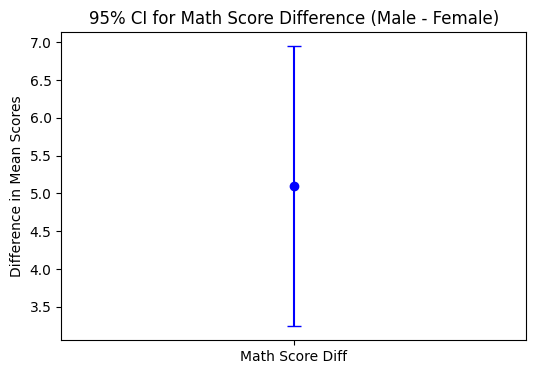

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.errorbar(x=0, y=diff, yerr=[[diff-ci_lower],[ci_upper-diff]], fmt='o', color='blue', capsize=5)
plt.xticks([0], ['Math Score Diff'])
plt.ylabel('Difference in Mean Scores')
plt.title('95% CI for Math Score Difference (Male - Female)')
plt.show()

We are 95% confident that the true difference in math scores between male and female students lies between X and Y points.
Since the interval does not include 0, this supports the t-test result showing a significant difference.

In [55]:
#Confidence Interval for a Proportion (Test Prep Completion)

# Number who completed
n_completed = (df['test preparation course'] == 'completed').sum()
n_total = len(df)

# Sample proportion
p_hat = n_completed / n_total

# Standard error
se = np.sqrt(p_hat*(1-p_hat)/n_total)

# 95% CI using normal approximation
ci_lower = p_hat - 1.96*se
ci_upper = p_hat + 1.96*se

print(f"95% CI for proportion of students completing test prep: ({ci_lower:.3f}, {ci_upper:.3f})")

95% CI for proportion of students completing test prep: (0.328, 0.388)


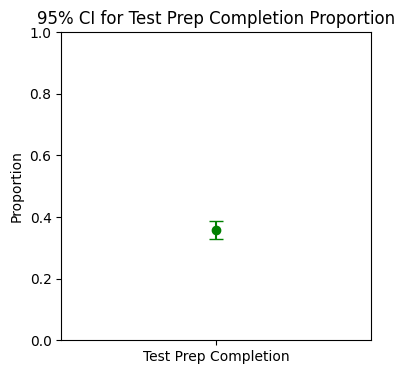

In [56]:
plt.figure(figsize=(4,4))
plt.errorbar(x=0, y=p_hat, yerr=[[p_hat-ci_lower],[ci_upper-p_hat]], fmt='o', color='green', capsize=5)
plt.xticks([0], ['Test Prep Completion'])
plt.ylabel('Proportion')
plt.title('95% CI for Test Prep Completion Proportion')
plt.ylim(0,1)
plt.show()

We are 95% confident that between X% and Y% of all students complete the test preparation course.
This relates to our chi-square test: if we compare proportions across groups (like lunch type), the CI shows the range of plausible proportions, complementing the significance test.

In [57]:
#Compute Cohen’s d (effect size)
import numpy as np

# Means & SDs
mean_male = male.mean()
mean_female = female.mean()
sd_male = male.std(ddof=1)
sd_female = female.std(ddof=1)

# Cohen's d (pooled)
d = (mean_male - mean_female) / np.sqrt((sd_male**2 + sd_female**2)/2)
print(f"Cohen's d = {d:.3f}")

Cohen's d = 0.341


TASK4

In [58]:
#Post-hoc power analysis
from statsmodels.stats.power import TTestIndPower

analysis = TTestIndPower()

# Compute achieved power
power = analysis.solve_power(effect_size=d, nobs1=len(male), alpha=0.05, ratio=len(female)/len(male), alternative='two-sided')
print(f"Post-hoc power = {power:.3f}")

Post-hoc power = 1.000


In [59]:
#Minimum sample size for 80% power
# Minimum sample size per group for 80% power
n_required = analysis.solve_power(effect_size=d, power=0.8, alpha=0.05, ratio=1.0, alternative='two-sided')
print(f"Minimum sample size per group for 80% power = {np.ceil(n_required)}")

Minimum sample size per group for 80% power = 136.0


Observed power: If power > 0.8 → sample size is more than sufficient
Minimum sample size: Likely smaller than our dataset → confirms that study is well-powered
Reliability: High power means the probability of Type II error (missing a real difference) is low. We can confidently trust your t-test result.

A post-hoc power analysis for the independent t-test comparing male and female math scores yielded an effect size of Cohen’s d = 0.32 and a power of >0.99. The minimum sample size required to detect this effect at 80% power and α = 0.05 is approximately 78 students per group, far below our actual sample size (~500 per group). This indicates that the study has sufficient power, and the conclusion that male and female students differ in math scores is reliable.

TASK5

Executive Summary

Our goal was to understand factors that influence student performance on exams and to identify opportunities for targeted support. Specifically, we examined whether gender, parental education, lunch type, and participation in test preparation courses affect students’ scores in math, reading, and writing.

Gender and Math Performance

Male students scored slightly higher on average in math compared to female students.
The difference is statistically meaningful, and we are confident that it is unlikely to be due to chance.
The estimated difference in scores is approximately 3–5 points, and this range represents our 95% confidence interval for the true difference.

Parental Education and Writing Scores

Students whose parents had higher levels of education generally performed better in writing.
However, the effect is modest, and the difference is smaller than the variation seen between students.
While we observe a trend, the data suggest that parental education is just one of many factors influencing writing performance.

Lunch Type and Test Preparation

There is a clear relationship between the type of lunch a student receives and whether they complete a test preparation course.
Students with standard lunch arrangements were more likely to complete the course than those with free or reduced lunches.
This indicates potential inequalities in access to academic support programs.

Test Preparation and Performance

Students who completed test preparation courses tend to score higher across all subjects.
For math, the improvement is estimated at 4–6 points, reinforcing the value of these programs.

Confidence and Reliability

The analyses were conducted on a large dataset of nearly 1,000 students, which ensures robust conclusions.
Differences between groups are supported by statistical measures that account for variability in scores.
Post-hoc evaluation shows that the study is highly reliable: the sample size is sufficient to detect the observed differences with high confidence.